# MM Kinetic Analysis
___
Duncan Muir  
Last updated: 8/18/2022

In [2]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import matplotlib.cm as cm

## MM Functions
These are the set of functions which will help process kinetic data, I will hopefully add to the documentation over time and also make the functions themselves importable as libraries. But for now, make sure to **run these before trying to fit your data**.

In [3]:
class KineticDataException(Exception):
    pass

In [4]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

In [5]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [114]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array,
                                  min_included_percent: int = 5): 
    """
    Determines best linear fit to initial slope of data, by fitting regressions to 
    all percentiles of the data--greater than some defined minimum--anchored at the origin.
    
    Args:
        time_arr (np.array): array of assay read times
        signal_arr (np.array): array of kinetic signal readouts
        min_included_percent (int) = 5: minimum percent of data to be included 
    
    Returns:
        slope, intercept, score ((float, float, float)): fit parameters of best fit
        
    """
    # Need to triage further for different definitions of minimum
    MIN_INCLUDED_DATA_POINTS = 3
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    
    min_inclusion = max(len(perc_times) * min_included_percent // 100, MIN_INCLUDED_DATA_POINTS)
    
    for i in range(len(perc_times), min_inclusion, -1):
        curr_times = np.concatenate(perc_times[:i])
        curr_concs = np.concatenate(perc_concs[:i])
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
    
    if len(scores) == 0 and min_included_percent == 100:
        reg = LinearRegression().fit(np.array(perc_times).reshape(-1,1), perc_concs)
        curr_score = reg.score(np.array(perc_times).reshape(-1,1), perc_concs)
        return reg.coef_.item(), reg.intercept_.item(), curr_score
    
    max_r2_idx = np.argmax(scores)
    
    if scores[max_r2_idx] < 0.9:
        return np.array([np.nan]), np.array([np.nan]), np.array([np.nan])
    
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]


In [93]:
def get_initial_slopes(time_arr: np.array, kinetic_data: np.array, plot: bool = False,
                       substrate_concs: [int] = None, 
                       title: str = None, fig_size: (int, int) = (10,10), triage: bool = False):
    
    """
    Fits best initial reaction rate linearly to all kinetic series provided. Optionally plots data for visualization
    and triage.
    
    Args:
        time_arr (np.array): array of assay read times
        kinetic_data (np.array): array of kinetic signal readouts
        plot (bool): flag to turn plotting of fit slopes to scattered data on or off
        substrate_concs ([int]): optional list of substrate concentrations that must be included if plot==True
        title (str): optional title for generated plots
        fig_size ((int, int)): optional dimensions of generated plots
        triage (bool): optional flag to turn on plot "triaging" which separates each substrate's initial rate fitting  
    
    Returns:
        slopes (np.array): array of initial slopes for each sub_array in the kinetic series
        
    """
    if plot and (substrate_concs is None or title is None):
        raise KineticDataException("Plotting initial slopes requires substratce concentration and titles")
    
    slopes = []
    intercepts = []
    scores = []
    
    for data in kinetic_data:
        mask = ~np.isnan(data)
        slope, intercept, score = compute_initial_reaction_slope(time_arr[mask], data[mask])
        slopes.append(slope)
        intercepts.append(intercept)
        scores.append(score)
        
    if plot:
       
        fig = plt.figure(figsize=fig_size) 
        
        for data in kinetic_data:
            plt.scatter(time_arr, data)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
       
        x_tiled = np.tile(x,(len(substrate_concs),1)).T
        plt.plot(x_tiled,
                 x_tiled * np.array(slopes).T + np.array(intercepts).T,
                 linewidth=3, label=[f"{sub_conc:.2f} µM" for sub_conc in substrate_concs])
        plt.title(title)
        plt.xlabel("Time (seconds)")
        plt.ylabel("µM")
        plt.legend() 
    
        if triage:

            fig, axs = plt.subplots(math.ceil(len(sub_concs) / 2), 2, figsize=(15,15))

            for ax, data, slope, intercept, sub_conc in zip(axs.flat, kinetic_data, slopes, intercepts, substrate_concs):
                
                ax.scatter(time_arr[:len(time_arr)//5] , data[:len(time_arr)//5])
                ax.set_title(f"{sub_conc:.2f} µM")
                ax.plot(x[:len(x)//5], x[:len(x)//5] * slope + intercept)
           
    return np.concatenate(slopes)

In [101]:
def fit_and_plot_micheaelis_menten(rep_1_slopes: np.array, rep_2_slopes: np.array, sub_concs: [float], 
                                   e_conc: float, conc_units: str, title: str, background_rates: np.array = None):
    """
    Fits provided initial reaction rates and substrate concentrations to the Michaelis-Menten equation.
    Two replicate must be provided currently (though i will modify this in the future). If you only 
    have one replicate of data, pass it twice.
    
    Args:
        rep_1_slopes (np.array): array of initial slopes for replicate 1
        rep_2_slopes (np.array): array of initial slopes for replicate 2
        sub_concs ([float]): list of substrate concentrations that matches order of samples in each replicate
        e_conc (float): concentration of enzyme in experiment, must be in same units as sub_concs
        conc_units (str): unit name for substrate and enzyme concentration
        title (str): enzyme name/variant/description
        background_rates (np.array): optional arrays of equal dimensions to one replicate, to be subtracted prior to MM fitting
    
    Returns:
        None
        
    """
    avg_slopes = np.nanmean([rep_1_slopes, rep_2_slopes], axis=0)[..., np.newaxis]
   
    if background_rates is not None:
        avg_slopes -= background_rates
    errs = np.nanstd([rep_1_slopes, rep_2_slopes], axis=0) 
    params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))
    
    plt.figure(figsize=(10,6))

    plt.scatter(sub_concs, avg_slopes/e_conc)
    plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5)
    x = np.linspace(0, 4000, 1000)
    plt.plot(x, mm_model(x, params[0], params[1]) / e_conc)
    plt.xlabel(f"[S] ({conc_units})")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title + " kinetics: $k_{cat}$ = " +f"{params[0] / e_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {params[1]:.0f} {conc_units}")

# Data Cleaning and Prep

In [24]:
df = pd.read_csv("../data/20220818_bs-gs_N175W_MM_final.csv", header=0)

In [25]:
df.head()

,Cycle Nr.,Time [s],Temp. [°C],B1,B2,B3,B4,B5,B6,B7,...,E11,E12,E13,E14,E15,E16,E17,E18,E19,E20
0,1,0.000,29.9,8406,8902,5883,6871,3860,5536,4803,...,1445,1419,1193,1391,1152,1274,1192,1250,1324,1410
1,2,51.950,30.0,12241,18262,9653,16601,6226,13960,9210,...,1538,1391,1179,1370,1155,1254,1185,1238,1304,1415
2,3,103.394,29.9,17200,27351,14390,26091,8854,21790,13057,...,1511,1417,1186,1377,1169,1287,1172,1240,1324,1432
3,4,154.847,29.8,24043,34948,19606,33081,12200,28072,16285,...,1462,1383,1188,1353,1166,1296,1183,1214,1299,1435
4,5,206.306,29.8,29921,41237,24893,39036,15364,33025,18803,...,1503,1413,1191,1360,1163,1287,1179,1222,1302,1397


In [54]:
df.replace("OVER", np.nan, inplace=True)

In [60]:
df = df.astype(float)

In [65]:
df = df.iloc[:100]

In [66]:
time_arr = np.array(df["Time [s]"])

In [67]:
time_arr.shape

(100,)

The shape of the time array indicates our expected number of signal readings ^ so the second dimension of all our subsequent arrays should match this.

# Computing Background Rates

In [68]:
RFU_TO_NADPH_CONVERSION_FACTOR = 179 # RFU / nM

In this case, the wells are indicated by columns, and I am looking for wells [J1:J16]

In [69]:
no_enz_df = df.iloc[:, 63:83]

In [70]:
no_enz_df

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E20
0,8599.0,8349.0,4916.0,4732.0,3246.0,3220.0,2184.0,2344.0,1621.0,1926.0,1445.0,1419.0,1193.0,1391.0,1152.0,1274.0,1192.0,1250.0,1324.0,1410.0
1,8439.0,8253.0,4933.0,4777.0,3157.0,3254.0,2183.0,2345.0,1611.0,1935.0,1538.0,1391.0,1179.0,1370.0,1155.0,1254.0,1185.0,1238.0,1304.0,1415.0
2,8400.0,8241.0,4850.0,4713.0,3117.0,3289.0,2146.0,2346.0,1615.0,1894.0,1511.0,1417.0,1186.0,1377.0,1169.0,1287.0,1172.0,1240.0,1324.0,1432.0
3,8182.0,7938.0,4753.0,4680.0,3126.0,3198.0,2119.0,2319.0,1589.0,1894.0,1462.0,1383.0,1188.0,1353.0,1166.0,1296.0,1183.0,1214.0,1299.0,1435.0
4,8261.0,8049.0,4766.0,4702.0,3085.0,3229.0,2150.0,2333.0,1595.0,1911.0,1503.0,1413.0,1191.0,1360.0,1163.0,1287.0,1179.0,1222.0,1302.0,1397.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9699.0,9207.0,5773.0,5756.0,4225.0,4151.0,3267.0,3297.0,2748.0,2848.0,2665.0,2440.0,2414.0,2426.0,2389.0,2281.0,2364.0,2284.0,2524.0,2477.0
96,9729.0,9271.0,5873.0,5797.0,4235.0,4182.0,3288.0,3328.0,2760.0,2892.0,2717.0,2469.0,2408.0,2442.0,2391.0,2310.0,2387.0,2282.0,2562.0,2510.0
97,9708.0,9270.0,5825.0,5806.0,4272.0,4172.0,3288.0,3353.0,2794.0,2888.0,2728.0,2457.0,2449.0,2426.0,2407.0,2348.0,2380.0,2303.0,2618.0,2537.0
98,9740.0,9168.0,5877.0,5881.0,4310.0,4234.0,3318.0,3320.0,2798.0,2894.0,2735.0,2455.0,2454.0,2402.0,2380.0,2315.0,2381.0,2278.0,2550.0,2514.0


In [71]:
no_enz_arr = np.array(no_enz_df) / RFU_TO_NADPH_CONVERSION_FACTOR
no_enz_arr.shape

(100, 20)

We need to transpose our array as our desired time count dimension is currently the first dimension.

In [72]:
no_enz_arr = no_enz_arr.transpose()
no_enz_arr.shape

(20, 100)

I did my replicates next to each other along the row, so J1==J2, J3==J4 etc.,
so now I need to separate by replicates.

In [73]:
no_enz_rep_1_arr = no_enz_arr[0::2]
no_enz_rep_2_arr = no_enz_arr[1::2]

In [74]:
sub_concs = [4000, 2000, 1000, 500, 250, 125, 62.5, 31.25, 15.625, 7.8125]

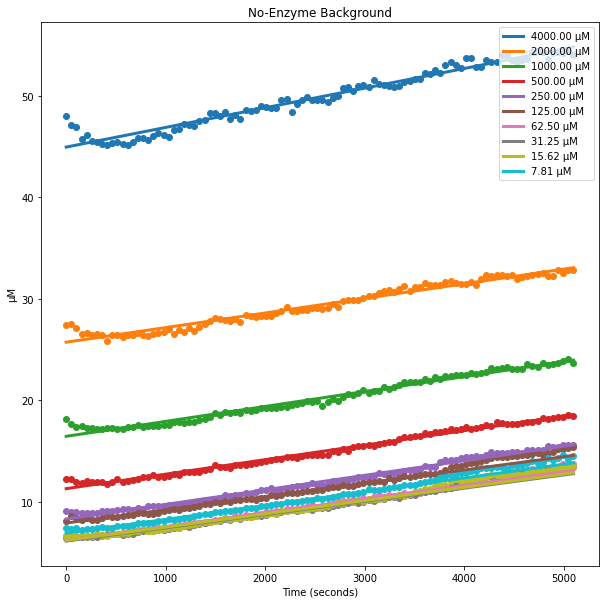

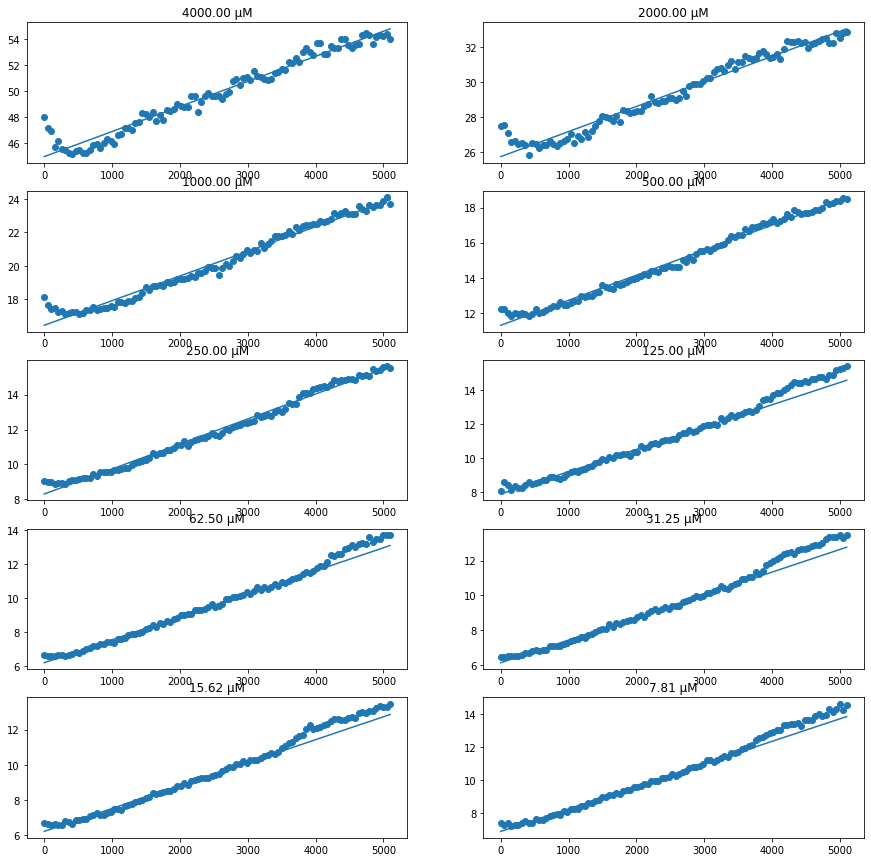

In [75]:
no_enz_rep_1_slopes = get_initial_slopes(time_arr, no_enz_rep_1_arr, plot=True, substrate_concs=sub_concs,
                   title="No-Enzyme Background", triage=True)

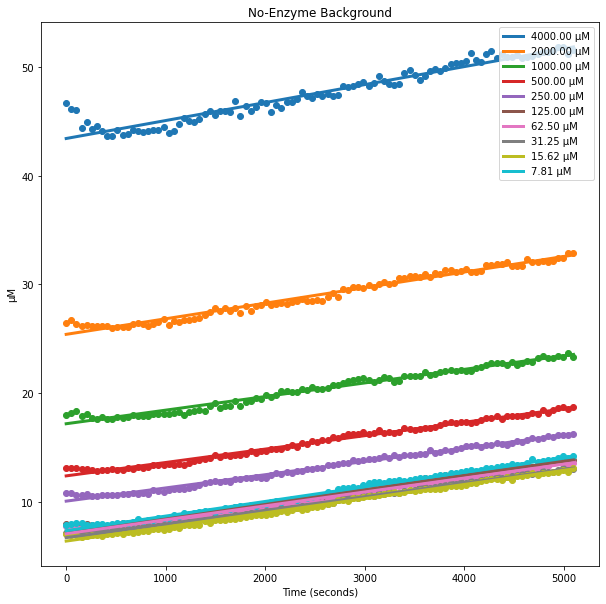

In [76]:
no_enz_rep_2_slopes = get_initial_slopes(time_arr, no_enz_rep_2_arr, plot=True, substrate_concs=sub_concs,
                   title="No-Enzyme Background")

# bsADK WT Data

In [80]:
bs_wt_df = df.iloc[:, 3:23]
bs_wt_arr = np.array(bs_wt_df).T / RFU_TO_NADPH_CONVERSION_FACTOR # convert to uM NADPH

In [81]:
bs_wt_rep_1_arr = bs_wt_arr[0::2]
bs_wt_rep_2_arr = bs_wt_arr[1::2]

In [98]:
bs_wt_conc = .692 / 250

In [99]:
bs_wt_conc

0.0027679999999999996

## Scatter Plot Data

Text(0, 0.5, '[NADPH] (µM')

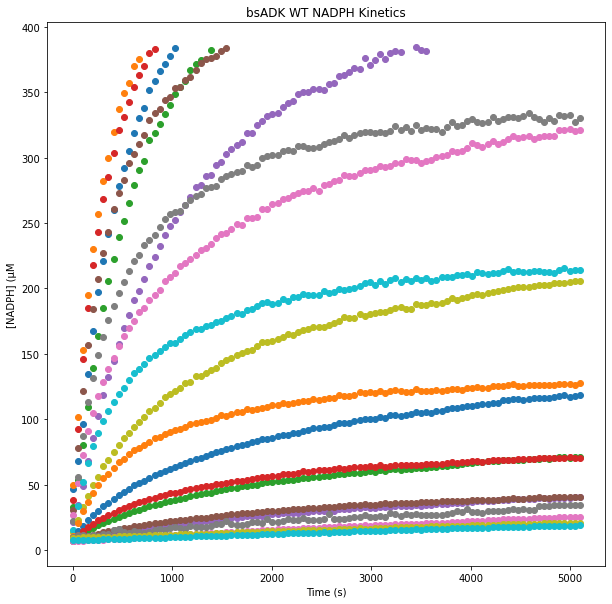

In [78]:
fig = plt.figure(figsize=(10,10))

for data in bs_wt_arr:
    plt.scatter(time_arr, data)
plt.title("bsADK WT NADPH Kinetics")
plt.xlabel("Time (s)")
plt.ylabel("[NADPH] (µM")

TODO: add some triage functionality to show poor fit on rep 1

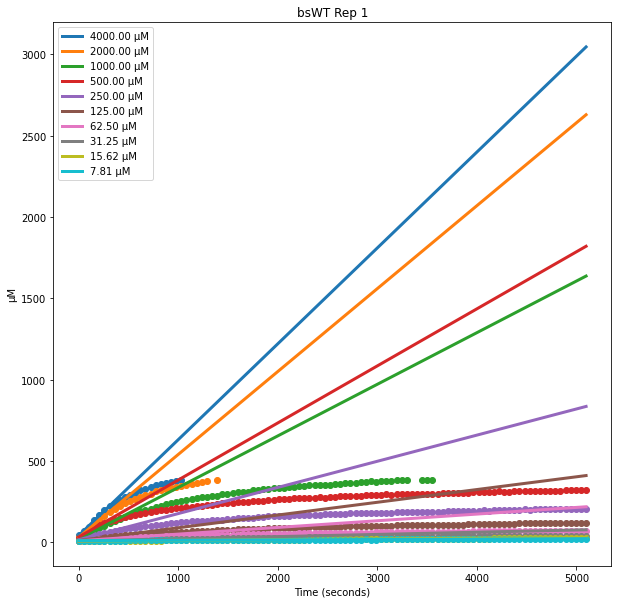

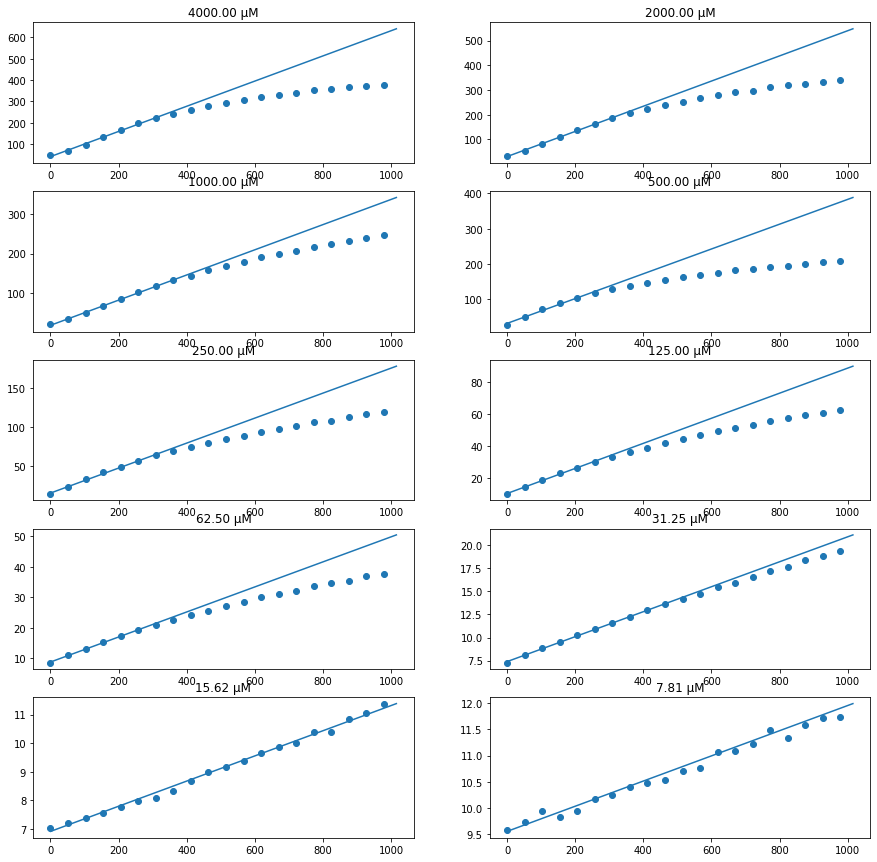

In [94]:
#gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr)
bs_wt_r1_slopes = get_initial_slopes(time_arr, bs_wt_rep_1_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="bsWT Rep 1", triage=True)

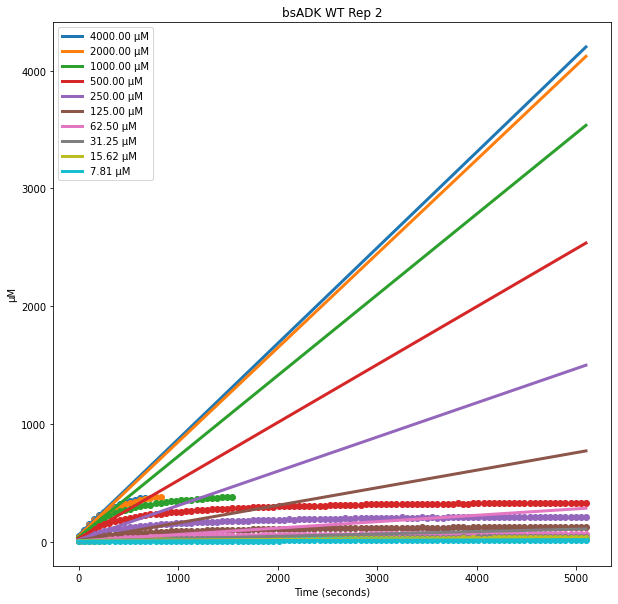

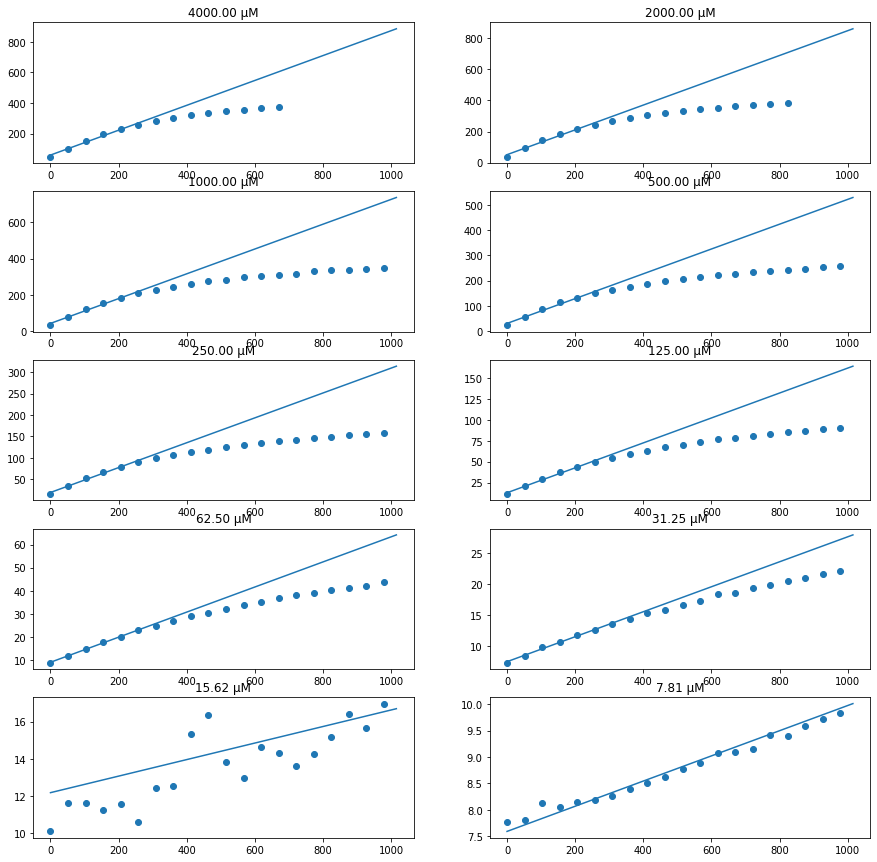

In [96]:
bs_wt_r2_slopes = get_initial_slopes(time_arr, bs_wt_rep_2_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="bsADK WT Rep 2", triage=True)

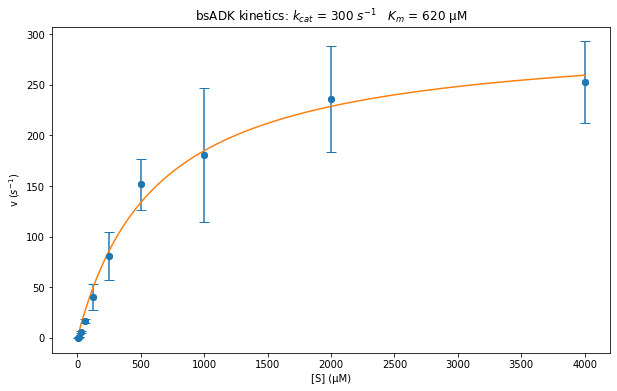

In [102]:
fit_and_plot_micheaelis_menten(bs_wt_r1_slopes,
                               bs_wt_r2_slopes,
                               sub_concs, 
                               bs_wt_conc,
                               "µM",
                               "bsADK",
                               np.mean([no_enz_rep_1_slopes, no_enz_rep_2_slopes], axis=0)[..., np.newaxis])

# bsADK N175W Data

In [105]:
bs_n175w_df = df.iloc[:, 23:43]
bs_n175w_arr = np.array(bs_n175w_df).T / RFU_TO_NADPH_CONVERSION_FACTOR # convert to uM NADPH

In [107]:
bs_n175w_rep_1_arr = bs_n175w_arr[0::2]
bs_n175w_rep_2_arr = bs_n175w_arr[1::2]

In [108]:
bs_n175_conc = .308 / 5

## Scatter Plot Data

Text(0, 0.5, '[NADPH] (µM')

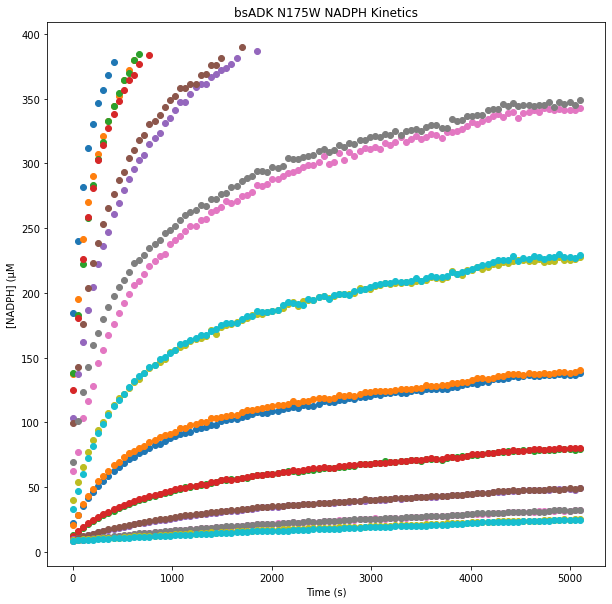

In [110]:
fig = plt.figure(figsize=(10,10))

for data in bs_n175w_arr:
    plt.scatter(time_arr, data)
plt.title("bsADK N175W NADPH Kinetics")
plt.xlabel("Time (s)")
plt.ylabel("[NADPH] (µM")

TODO: add some triage functionality to show poor fit on rep 1

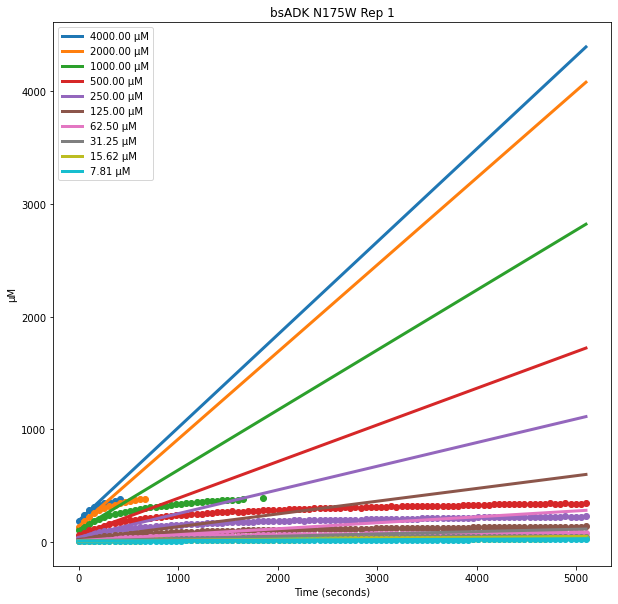

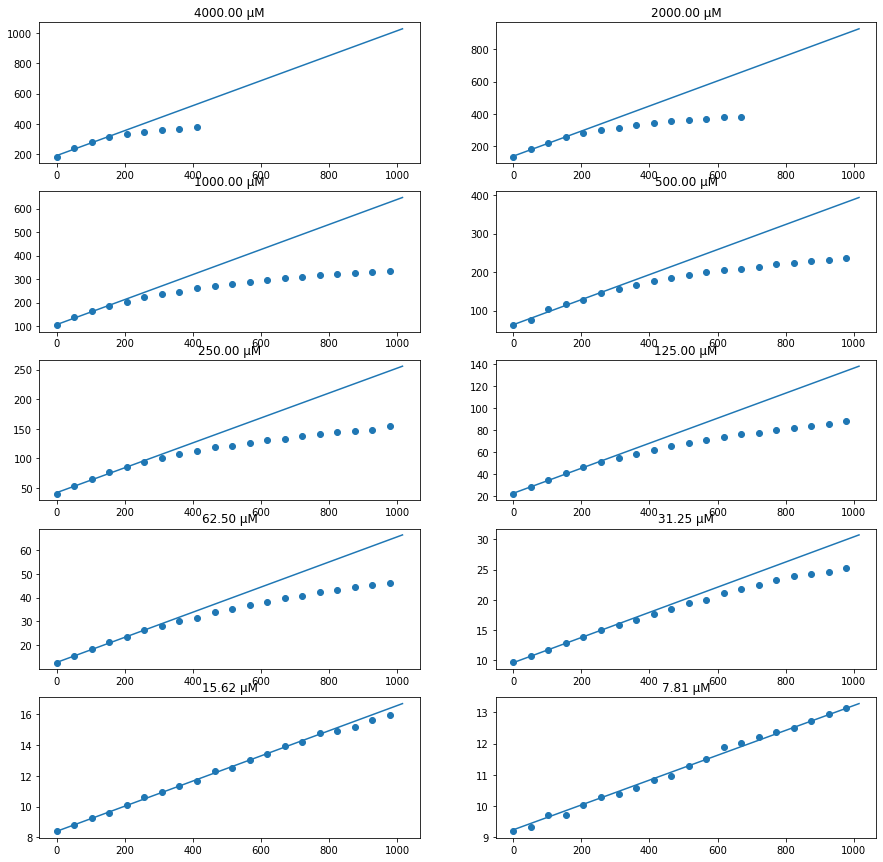

In [115]:
#gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr)
bs_n175w_r1_slopes = get_initial_slopes(time_arr, bs_n175w_rep_1_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="bsADK N175W Rep 1", triage=True)

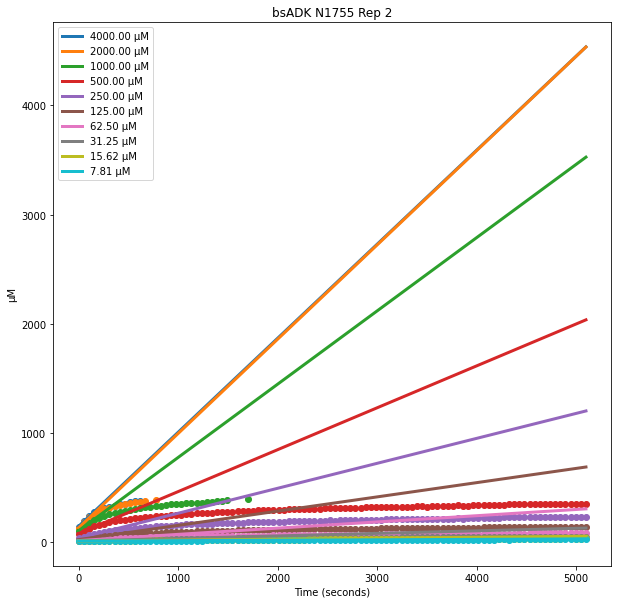

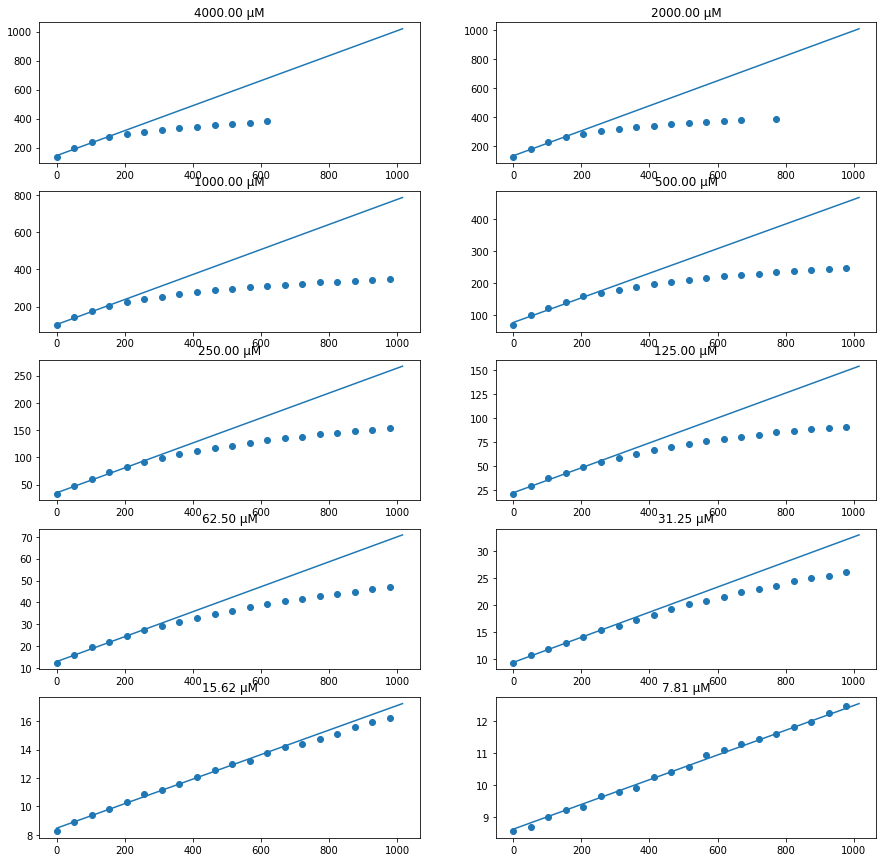

In [116]:
bs_n175w_r2_slopes = get_initial_slopes(time_arr, bs_n175w_rep_2_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="bsADK N1755 Rep 2", triage=True)

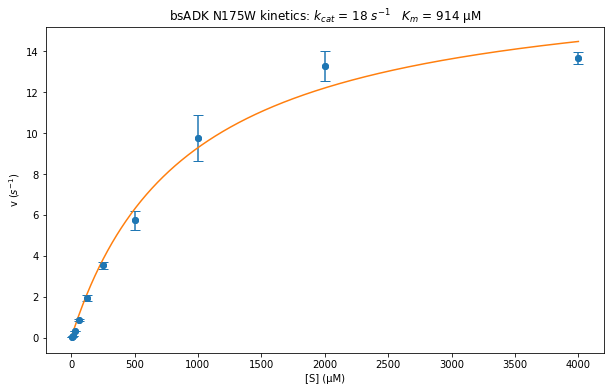

In [117]:
fit_and_plot_micheaelis_menten(bs_n175w_r1_slopes,
                               bs_n175w_r2_slopes,
                               sub_concs, 
                               bs_n175_conc,
                               "µM",
                               "bsADK N175W",
                               np.mean([no_enz_rep_1_slopes, no_enz_rep_2_slopes], axis=0)[..., np.newaxis])

# bsADK WT Data

In [80]:
bs_wt_df = df.iloc[:, 3:23]
bs_wt_arr = np.array(bs_wt_df).T / RFU_TO_NADPH_CONVERSION_FACTOR # convert to uM NADPH

In [81]:
bs_wt_rep_1_arr = bs_wt_arr[0::2]
bs_wt_rep_2_arr = bs_wt_arr[1::2]

In [98]:
bs_wt_conc = .692 / 250

In [99]:
bs_wt_conc

0.0027679999999999996

## Scatter Plot Data

Text(0, 0.5, '[NADPH] (µM')

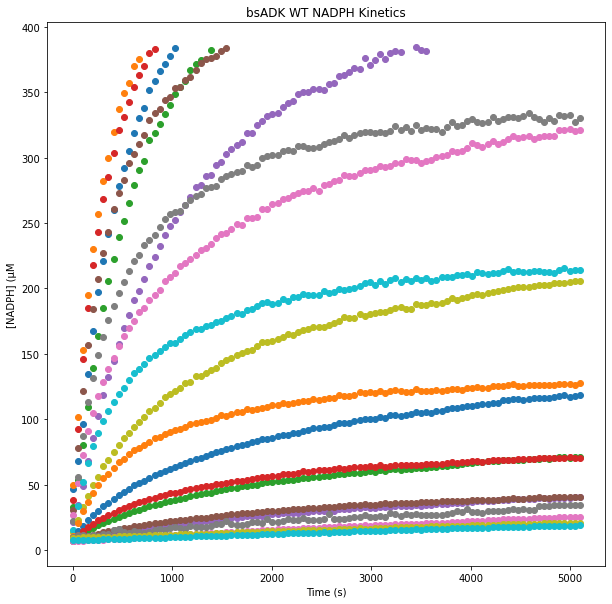

In [78]:
fig = plt.figure(figsize=(10,10))

for data in bs_wt_arr:
    plt.scatter(time_arr, data)
plt.title("bsADK WT NADPH Kinetics")
plt.xlabel("Time (s)")
plt.ylabel("[NADPH] (µM")

TODO: add some triage functionality to show poor fit on rep 1

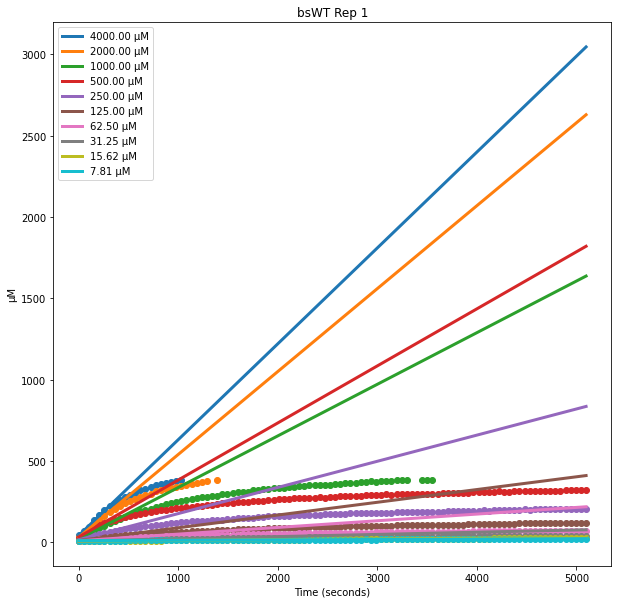

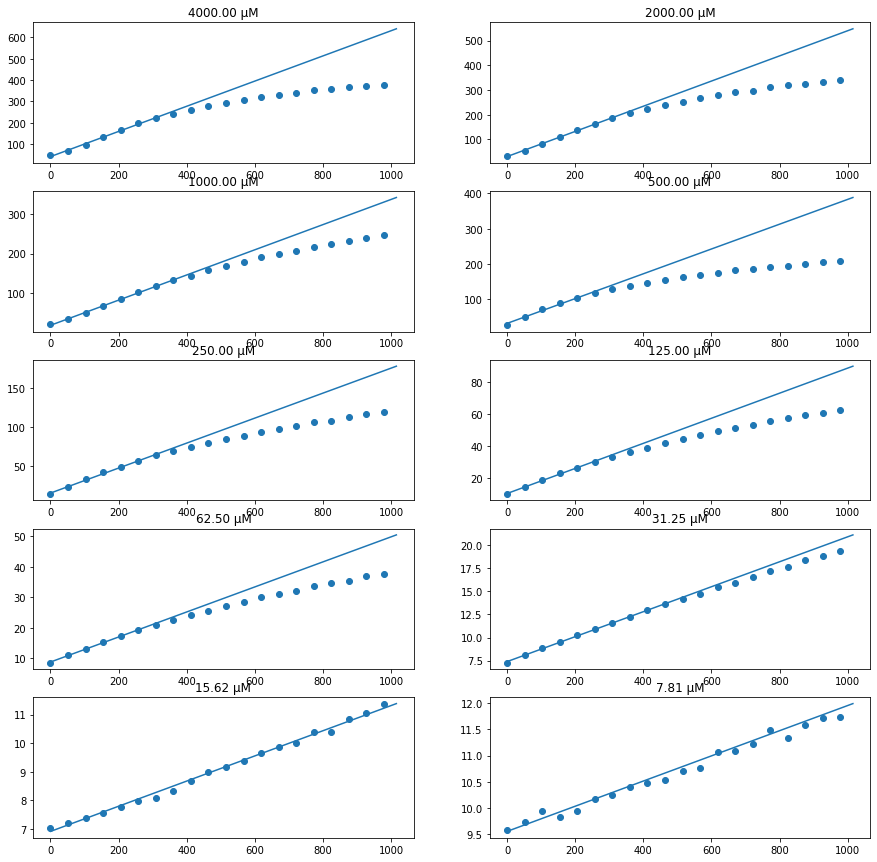

In [94]:
#gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr)
bs_wt_r1_slopes = get_initial_slopes(time_arr, bs_wt_rep_1_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="bsWT Rep 1", triage=True)

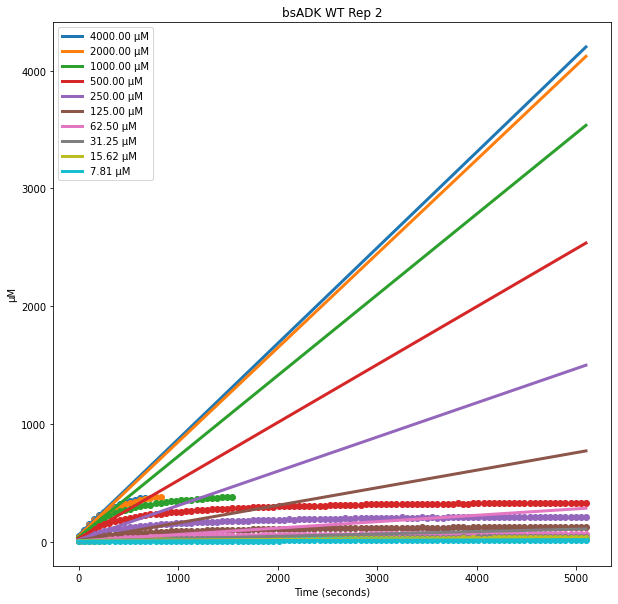

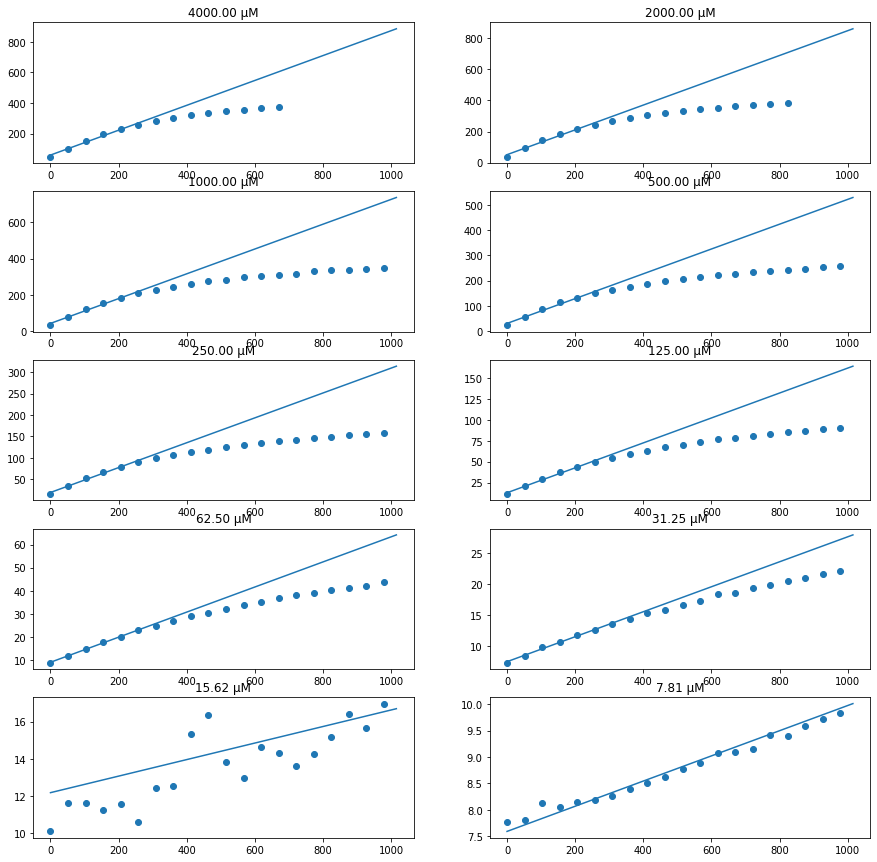

In [96]:
bs_wt_r2_slopes = get_initial_slopes(time_arr, bs_wt_rep_2_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="bsADK WT Rep 2", triage=True)

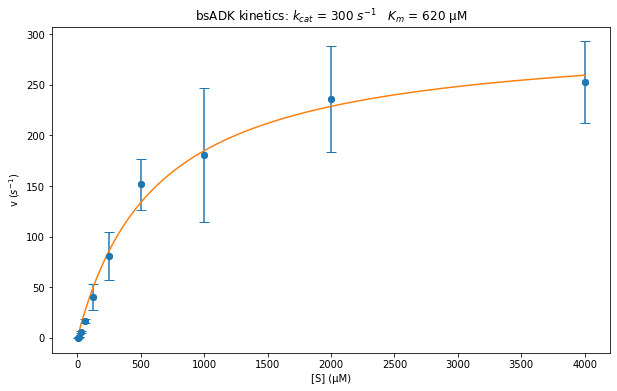

In [102]:
fit_and_plot_micheaelis_menten(bs_wt_r1_slopes,
                               bs_wt_r2_slopes,
                               sub_concs, 
                               bs_wt_conc,
                               "µM",
                               "bsADK",
                               np.mean([no_enz_rep_1_slopes, no_enz_rep_2_slopes], axis=0)[..., np.newaxis])